In [ ]:
import os
import datetime
# from netCDF4 import Dataset
import numpy as np
import pandas as pd
import xarray as xr
from scipy import signal, integrate, stats
import yaml
import importlib
import multiprocessing as mp
import time

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib
from matplotlib.colors import BoundaryNorm, LogNorm
from matplotlib.ticker import MultipleLocator, FormatStrFormatter, AutoMinorLocator
from matplotlib.ticker import MaxNLocator
from mpl_toolkits.mplot3d import Axes3D, axes3d

import cmaps, plt_helper, filter

plt.style.use('latex_default.mplstyle')

In [2]:
import mpmath

# --- Nondimensional Blumen (1965) drag for Witch-of-Agnesi, as a function of a ---
def blumen65_nd_for_a(a, U, N, f):
    """
    Nondimensional drag D* = D / (rho0 * U * N * h_m**2)
    for a 2D Witch-of-Agnesi ridge, using Fourier conv.  ĥ(k) = (1/2π)∫ h e^{-ikx} dx.
    """
    if not (a > 0 and U > 0 and 0 <= f < N):
        return np.nan

    mu   = U / (a * N)      # nonhydrostatic parameter
    beta = f * a / U        # rotation parameter

    kmin = beta
    kmax = 1.0 / mu
    if not (kmin < kmax):
        return 0.0  # no propagating waves

    # tiny padding away from endpoints
    eps_left  = 1e-12 * (1 + kmin)
    eps_right = 1e-12 * (1 + kmax)
    a1 = kmin + eps_left
    b1 = kmax - eps_right
    if a1 >= b1:
        return 0.0

    def integrand(kappa):
        if kappa == 0:
            return mpmath.mpf('0.0')
        nh_arg = 1.0 - (mu * kappa)**2
        nh_arg = nh_arg if nh_arg > 0 else 0.0
        if beta == 0.0:
            f_fac = 1.0
        else:
            f_arg = 1.0 - (beta / kappa)**2
            f_arg = f_arg if f_arg > 0 else 0.0
            f_fac = mpmath.sqrt(f_arg)
        return kappa * mpmath.e**(-2.0 * kappa) * mpmath.sqrt(nh_arg) * f_fac

    I_mid   = mpmath.quad(integrand, [a1, b1])
    I_left  = mpmath.quad(integrand, [kmin, a1])
    I_right = mpmath.quad(integrand, [b1, kmax])

    I = I_left + I_mid + I_right

    # Correct prefactor to achieve D* → π/4 in the (β=0, μ→0) limit
    Dstar = mpmath.pi * I
    return float(mpmath.re(Dstar))


# --- New: Nonhydrostatic, nonrotating approximation (f = 0) ---
def blumen65_nonhydro_nd_for_a(a, U, N):
    """
    Nondimensional drag D* in the nonhydrostatic, nonrotating limit (f=0).
    D* = π ∫_{0}^{1/μ} κ e^{-2κ} sqrt(1 - μ^2 κ^2) dκ,  with μ = U/(a N).
    """
    if not (a > 0 and U > 0 and N > 0):
        return np.nan

    mu = U / (a * N)    # nonhydrostatic parameter
    kmin, kmax = 0.0, 1.0 / mu
    if not (kmin < kmax):
        return 0.0

    # tiny padding from the right endpoint where sqrt→0
    eps_right = 1e-12 * (1 + kmax)
    b1 = kmax - eps_right
    if b1 <= 0:
        return 0.0

    def integrand(kappa):
        nh_arg = 1.0 - (mu * kappa)**2
        nh_arg = nh_arg if nh_arg > 0 else 0.0
        return kappa * mpmath.e**(-2.0 * kappa) * mpmath.sqrt(nh_arg)

    I = (mpmath.quad(integrand, [0.0, b1]) +
         mpmath.quad(integrand, [b1, kmax]))
    return float(mpmath.pi * I)


# Parameters for Smith
a = 1e-5                                     # since 10^(-10) = a^2
# L_vals = np.linspace(1000.0, 100000.0, 100)  # 100 points (linear grid)
L_vals = np.geomspace(100, 300000, 300)

# Closed-form integral for ∫_a^∞ sqrt(k^2 - a^2) * exp(-2 L k) dk
# I(L) = (a / (2 L)) * K1(2 a L)
def I_a_to_inf(L):
    return (a / (2.0 * L)) * mpmath.besselk(1, 2.0 * a * L)

U = 10.0      # m/s
N = 0.01      # 1/s
f = 1.0e-4    # 1/s

# If you need to build it: choose an a-grid (here log-spaced 0.5–100 km)
smith79 = np.pi * (L_vals**2) * np.array([I_a_to_inf(L) for L in L_vals], dtype=float)
blumen65_nh = np.array([blumen65_nonhydro_nd_for_a(L, U, N) for L in L_vals])
blumen65 = np.array([blumen65_nd_for_a(L, U, N, f) for L in L_vals])

# Pack results
dfana = pd.DataFrame({
    "L": L_vals,
    "Smith79": smith79,
    "Blumen65_nh": blumen65_nh,
    "Blumen65": blumen65
})

# Save to CSV (optional)
# dfana.to_csv("dfana.csv", index=False)
# print("Saved to integral_results_L_100pts.csv")

# Quick peek
print(dfana.tail())

                 L   Smith79  Blumen65_nh  Blumen65
295  269528.430538  0.011108     0.785390  0.011108
296  276843.129837  0.009711     0.785390  0.009710
297  284356.341870  0.008456     0.785391  0.008455
298  292073.454050  0.007333     0.785391  0.007332
299  300000.000000  0.006333     0.785392  0.006333


In [3]:
importlib.reload(plt_helper)
folder = "/work/bd0620/b309199/linear-mws"
flavor = "pmap_ld"
# flavor = "pmap_ppm"
# flavor = "eulag_compressi"
# flavor = "eulag_anelastic"

image_folder = f"../data/pmap"
os.makedirs(image_folder,exist_ok=True)

sims = [f"{flavor}_MW_000km", f"{flavor}_MW_001km", f"{flavor}_MW_002km", f"{flavor}_MW_003km", f"{flavor}_MW_005km", f"{flavor}_MW_010km", 
        f"{flavor}_MW_025km", f"{flavor}_MW_050km", f"{flavor}_MW_075km", f"{flavor}_MW_100km", 
        f"{flavor}_MW_125km", f"{flavor}_MW_150km"]

# sims = [f"{flavor}_MW_000km", f"{flavor}_MW_001km", f"{flavor}_MW_010km", f"{flavor}_MW_050km", f"{flavor}_MW_100km", f"{flavor}_MW_125km", f"{flavor}_MW_150km"]

# sims = [f"{flavor}_MW_010km"]

ds_list = []
cfgs = []
t = None
print("Starting...")
for sim in sims:
    model = flavor.split("_")[0]
    fpath = os.path.join(folder, sim)
    
    if model == "pmap":
        ds, _, cfg = plt_helper.preprocess_pmap(fpath, t=t, slices={"x": 0, "y": 0, "z": [0]})
        cfgs.append(cfg)
    else:
        _, ds, _, _ = plt_helper.preprocess_eulag_tstep(fpath, t, slices={"x": 0, "y": 0, "z": [0]})
    ds_list.append(ds)
print("DONE")

Starting...
DONE


L: 0.5km done
L: 1.0km done
L: 2.0km done
L: 3.0km done
L: 5.0km done
L: 10.0km done
L: 25.0km done
L: 50.0km done
L: 75.0km done
L: 100.0km done
L: 125.0km done
L: 150.0km done


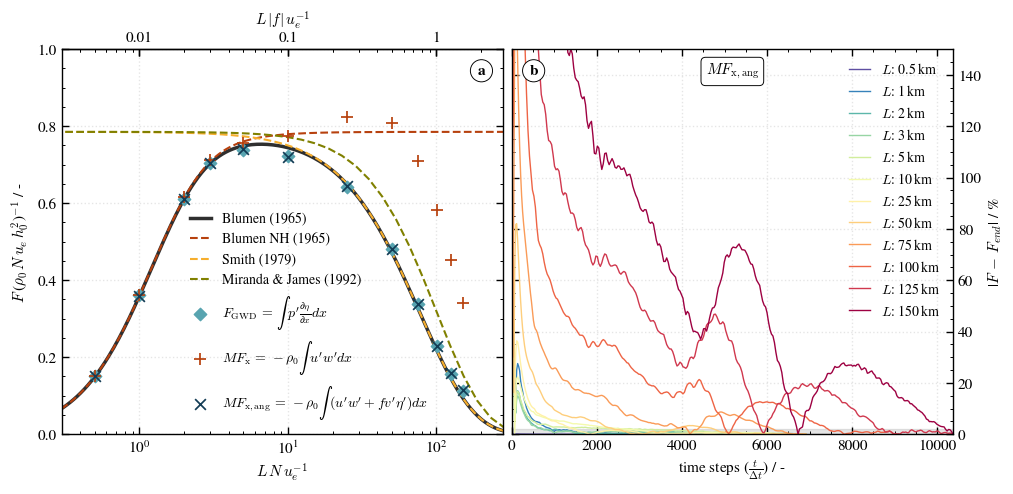

In [4]:
def plot_gwd_and_time(ds_list, cfgs, folder):

    fig, (ax0,ax1) = plt.subplots(1,2,figsize=(11.5,5), gridspec_kw={'wspace': 0.02})

    num_colors = len(ds_list)
    
    cmap = plt.get_cmap('Spectral')
    COLS = [cmap(i / (num_colors - 1)) for i in range(num_colors)]
    # COLS.pop(3)
    # COLS.pop(3)
    # COLS.pop(3)
    COLS = COLS[::-1]

    color_palette = [
        "#D72638",  # Crimson Red - Primary
        "#F46036",  # Coral Orange - Accent
        "#F6AE2D",  # Golden Sand - Highlight
        "mediumorchid",  # Teal Green - Complementary
        "#2F2F2F",  # Charcoal Gray - Neutral Base
        "grey",  # Mist White - Light Neutral
        "#58A4B0",  # Sky Blue - Cool Accent
        "#133C55"   # Midnight Blue - Deep Shade
    ]
    
    c1 = color_palette[-1]
    c2 = color_palette[-2] # 'mediumorchid'
    c3 = "#B7410E" # "#E2725B" # color_palette[0]
    
    lw_cross = 1.25
    lwall = 1.5
    a1 = 1
    mark1 = 'D'
    mark2 = 'x'
    mark4 = '+'
    mark3 = '.'
    ss = 60
    ss2 = 40

    for i, ds in enumerate(ds_list):
        model = flavor.split("_")[0]
        fpath = os.path.join(folder, sim)
        
        if model == "pmap":
            cfg = cfgs[i]
    
        if i == 0:
            if model == "pmap":
                U = cfg['ambient_fields']['velocity_x']
                grav = cfg['constants']['gravity0']
                stb00 = cfg['ambient_fields']['stb00']
                N = np.sqrt(stb00*grav)
                rho00 = cfg['ambient_fields']['rho00']
                AMP = cfg['define_orography']['args']['amplitude']
                f = cfg['constants']['fcoriolis0'] * np.sin(cfg['constants']['angle0']*np.pi/180)
            else:
                U = ds['u'][0,0].values
                grav = ds.g
                stb00 = ds.st
                N = np.sqrt(stb00*grav)
                rho00 = 1
                # rho00 = ds['rh0'][0,0,0].values
                AMP = ds.amp
                f = ds.fcr0 * np.sin(ds.ang*np.pi/180)
            # print(f"stb00: {stb00}")
            # print(f"N: {N}")
            # print(f"U: {U}")
            # print(f"rho00: {rho00}")
            # print(f"AMP: {AMP}")
            # print(f"f: {f}")
            
            # N=0.01
            # U=10
            # f=10**(-4)
            drag0 = rho00*U*N*AMP**2
            # print(f'Drag_0: {drag0}')
            
            # - Linear theory: Smith - #
            a = 0.63*U/f
            smith_x = a * N / U
            smith = 0.5 * np.pi/4 # drag dropped to half for af/U = 0.63 -> a = 63km
            # print(f'Theoretical maximum: {theoretical_max} (pi/4)')
            # print(f'Actual max of curve: {bessel_drag_max}, correction factor: {factor_corr}, correction factor_manual: {factor_corr_manual}, a: {a}')
            # ax0.scatter(smith_x, smith, marker='o', s=20, color=c_smith, alpha=0.6, lw=lw_cross) # label='expl. specified (Smith 1979)'
            # smith_x = 100000 * N / U
            # smith = 0.28*np.pi/4 # af/U = 1 -> a = 100km
            # ax0.scatter(smith_x, smith, marker='o', s=50, color='darkorchid', alpha=0.6, lw=lw_cross)
    
            # - Linear Theory: Miranda and James for large L - #
            XML = np.logspace(1,10,100)
            XVALUES = XML * N / U
            mirandaJames = np.pi/4 * (1+2*f*XML/U)*np.exp(-2*f*XML/U)
            
            ax0.plot(dfana['L']/1000,dfana['Blumen65'], color="#2F2F2F", lw=lwall+1, ls="-", label='Blumen (1965)')
            ax0.plot(dfana['L']/1000,dfana['Blumen65_nh'], color="#B7410E", lw=lwall, ls="--", label='Blumen NH (1965)')
            ax0.plot(dfana['L']/1000,dfana['Smith79'], color="#F6AE2D", lw=lwall, ls="--", label='Smith (1979)')
            ax0.plot(XVALUES,mirandaJames, color="#808000", lw=lwall, ls='--', label="Miranda & James (1992)")
            
        abs_factor = 1
        z = 0
        if model == "pmap":
            L = cfg['define_orography']['args']['halfwidth']
            x_regime = L * N / U
        
            if cfg['absorber']['xboundaries']:
                nrelax0 = int(cfg['absorber']['widthx'] / cfg['dx'] * abs_factor)
                nrelax1 = cfg['nx'] - nrelax0
            else:
                nrelax0 = 0
                nrelax1 = cfg['nx']

            if L == 100000:
                ds =ds.isel(time=range(0,260))
            zs = ds['zcr'][0,0,:].values
            dzdx_surf = np.gradient(zs, cfg['dx'], axis=0)
            pprime = ds['pprime']
            uprime = ds['u'] - U
            vprime = ds['v']
            wprime = ds['w']
            rhoprime = ds['rhoprime']
            # rho = ds['density']
            # rho0 = ds['rho0']
            # th = ds['theta_total']
            # thprime = ds['thprime']
            xcr = ds.x[nrelax0:nrelax1]
        else:
            # t = 4
            L = ds.xml
            x_regime = L * N / U
            
            if ds.irelx:
                nrelax0 = int(ds.dxabL/ds.dx00 * abs_factor)
                nrelax1 = ds.nx - nrelax0
            else:
                nrelax0 = 0
                nrelax1 = ds.nx
            zs = ds['zs'][0,:].values
            dzdx_surf = np.gradient(zs, ds.dx00, axis=0)
            pprime = ds['p']
            uprime = ds['u'] - U
            vprime = ds['v']
            wprime = ds['w']
            # rhoprime = ds['rhoprime']
            xcr = ds.xcr[0,nrelax0:nrelax1].values
            
        # - Drag form pressure perturbation - #
        drag = integrate.trapezoid(pprime[:,z,nrelax0:nrelax1] * dzdx_surf[nrelax0:nrelax1], xcr) # 0.3576
        # drag = integrate.simps(ds.pprime[12,z,y,:] * ds.dzdx_surf[y,:], 1000*ds.xcr[y,:])
    
        # - Drag from vertical flux of angular momentum (vertical momentum flux + streamwise Coriolis force) - # 
        drag_vertMom = -rho00* integrate.trapezoid(uprime[:,z,nrelax0:nrelax1] * wprime[:,z,nrelax0:nrelax1], xcr)
        drag_f = -f * rho00 * integrate.trapezoid(vprime[:,z,nrelax0:nrelax1] * zs[nrelax0:nrelax1], xcr)
        # drag_vertMom_v = -ds['rh0'][0,z,0,0]*integrate.trapezoid((ds.v[z,y,n_sponge:ds.nx-n_sponge]-ds.ve[z,y,n_sponge:ds.nx-n_sponge])*ds.w[z,y,n_sponge:ds.nx-n_sponge], 1000.*ds.xcr[y,n_sponge:ds.nx-n_sponge])
        
        # - Normalized drag - #
        AMP = cfg['define_orography']['args']['amplitude']
        drag0 = rho00*U*N*AMP**2
        drag         = drag         / drag0
        drag_vertMom = drag_vertMom / drag0
        drag_f       = drag_f       / drag0

        drag_angMom  = drag_vertMom + drag_f

        lw1 = 1
        if i==0:  
            ax0.scatter(x_regime, drag[-1], marker=mark1, s=ss2, color=c2, alpha=a1, zorder=8, label=r"$F_\mathrm{GWD}\,=\,\int$ $p' \frac{\partial \eta}{\partial x} dx$")
            ax0.scatter(x_regime, drag_vertMom[-1], marker=mark4, s=ss+20, color=c3, alpha=a1, lw=lw_cross, zorder=9, label=r"$MF_\mathrm{x}\,=\,-\rho_0 \int$ $u'w' dx$")
            ax0.scatter(x_regime, drag_angMom[-1], marker=mark2, s=ss, color=c1, alpha=a1, lw=lw_cross, zorder=10, label=r"$MF_\mathrm{x,ang}\,=\,-\rho_0 \int$ $(u'w' + fv' \eta')dx$")
            ax1.plot(ds.time / cfg['dt'], np.abs(drag_angMom - drag_angMom[-1]), color=COLS[i], lw=lw1, label=f"$L$: {L/1000}$\,$km")
        else:
            ax0.scatter(x_regime, drag[-1], marker=mark1, s=ss2, color=c2,alpha=a1, zorder=8)
            ax0.scatter(x_regime, drag_vertMom[-1], marker=mark4, s=ss+20, color=c3, alpha=a1, lw=lw_cross, zorder=9)
            ax0.scatter(x_regime, drag_angMom[-1], marker=mark2, s=ss, color=c1, alpha=a1, lw=lw_cross, zorder=10)
            ax1.plot(ds.time / cfg['dt'], np.abs(drag_angMom - drag_angMom[-1])/drag_angMom[-1]*100, color=COLS[i], lw=lw1, label=f"$L$: {int(L/1000)}$\,$km")
        print(f"L: {L/1000}km done")
        
    # - Formatting and saving - #
    xtick_labels_top = ['xx','xx','0.01','0.1','1','xx']
    
    ax0.set_ylim([0,1])
    ax0.set_xlim([3*10**(-1),2.8*10**(2)])
    ax0.xaxis.set_minor_locator(AutoMinorLocator(5))
    ax0.yaxis.set_minor_locator(AutoMinorLocator())
    ax0.set_xscale('log')
    # ax0.legend(loc='upper left')
    # handles, labels = ax0.get_legend_handles_labels()
    # ax0.legend(handles[::-1], labels[::-1], loc='lower center', frameon=False)
    leg = ax0.legend(handlelength=1.5, loc='lower center', fontsize=10, frameon=False)
    # ax0.set_ylabel(r'F ($\rho_0$ N U h$_m^2$)$^{-1}$ / -')
    ax0.set_ylabel(r'$F\,$($\rho_0 \, N \, u_e \, h_0^2$)$^{-1}$ / -')
    ax0.set_xlabel(r'$L\,N\,u_e^{-1}$')
    # ax0.tick_params(labeltop=True)
    ax0.grid()
    
    ax_t = ax0.secondary_xaxis('top')
    xticks = ax_t.get_xticks()
    ax_t.set_xticks(xticks)
    ax_t.set_xticklabels(xtick_labels_top)
    ax_t.set_xlabel(r"$L \, |f| \, u_e^{-1}$")
    
    # ax0.xaxis.set_minor_locator(AutoMinorLocator())
    # ax0.tick_params(which='minor', top=True)
    # ax_t.xaxis.set_minor_locator(AutoMinorLocator())

    ax1.legend(handlelength=1.5, loc='upper right', fontsize=10, frameon=False)
    ax1.xaxis.set_minor_locator(AutoMinorLocator())
    ax1.yaxis.set_minor_locator(AutoMinorLocator())
    ax1.grid()
    ax1.axhspan(0, 2, alpha=0.2, color="grey")
    ax1.set_ylim([0,0.5])
    ax1.set_ylim([0,150])
    # ax1.set_xlim([150,6912])
    ax1.set_xlim([0,10368])
    ax1.set_ylabel(r'|$F\,-\,F_{end}$| / %')
    ax1.set_xlabel(r'time steps ($\frac{t}{\Delta t}$) / -')
    # ax1.set_xscale('log')
    ax1.tick_params(axis="y", which='both', labelleft=False, labelright=True)
    ax1.yaxis.set_label_position("right")
    
    xlab = 0.96
    ylab = 0.935
    ax0.text(xlab, ylab, 'a', horizontalalignment='right', transform=ax0.transAxes, weight='bold', bbox={"boxstyle" : "circle", "lw":0.67, "facecolor":"white", "edgecolor":"black"})
    ax1.text(1-xlab, ylab, 'b', horizontalalignment='left', transform=ax1.transAxes, weight='bold', bbox={"boxstyle" : "circle", "lw":0.67, "facecolor":"white", "edgecolor":"black"})
    # ax1.text(0.5, 0.9, r"-$\rho_0 \int$ $(u'w' + fv' \eta')dx$", horizontalalignment='center', transform=ax1.transAxes, bbox={"boxstyle" : "round", "lw":0.67, "facecolor":"white", "edgecolor":"black"})
    ax1.text(0.5, ylab, r"$MF_\mathrm{x,ang}$", horizontalalignment='center', transform=ax1.transAxes, bbox={"boxstyle" : "round", "lw":0.67, "facecolor":"white", "edgecolor":"black"})

    plt.draw() # Draw the figure so you can find the positon of the legend. 
    bb = leg.get_bbox_to_anchor().transformed(ax0.transAxes.inverted()) 
    
    # Change to location of the legend. 
    xOffset = 0.06
    bb.x0 += xOffset
    bb.x1 += xOffset
    leg.set_bbox_to_anchor(bb, transform = ax0.transAxes)

    fig.show()
    # fig_title = f'surface_gwd_and_time_{flavor}.png'
    fig_title = f'surface_gwd_and_time_temp.png'
    fig.savefig(os.path.join(image_folder, fig_title), facecolor='w', edgecolor='w',
                    format='png', dpi=300, bbox_inches='tight')
    
plot_gwd_and_time(ds_list, cfgs, folder)

In [5]:
cfg['dt']

375.0